# Gelişmiş Model 1: AdaBoost Regressor
### Amaç: Boosting Yöntemi ve Veri Senaryolarının Analizi
Bu çalışmada, zayıf öğrenicileri sıralı bir şekilde eğiterek hataları düzelten **AdaBoost (Adaptive Boosting)** algoritması kullanılmıştır.

Çalışmanın özgünlüğünü artırmak adına, model sadece tek bir veri seti üzerinde değil, **4 farklı veri senaryosu** (Ham, PCA, Kümeleme, Hibrit) üzerinde test edilerek, "Hangi veri ön işleme tekniği AdaBoost için daha uygundur?" sorusuna yanıt aranmıştır.

In [21]:
# Gerekli Kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model ve İşleme
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Metrikler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Uyarıları kapat
import warnings
warnings.filterwarnings('ignore')

print("Kütüphaneler ve Metrikler yüklendi.")

Kütüphaneler ve Metrikler yüklendi.


### 1. Veri Yükleme ve Ön İşleme
Temizlenmiş veri seti yüklenir, kategorik değişkenler (Marka, Model vb.) sayısal formata çevrilir ve model başarısı için veriler standartlaştırılır (Scaling).erir.

In [22]:
# Veriyi Oku
df = pd.read_csv('ekip_odevi_temizlenmis_veri.csv')

# 1. Encoding
le = LabelEncoder()
df['model'] = le.fit_transform(df['model'])

# One-Hot Encoding
df = pd.get_dummies(df, columns=['marka', 'fuelType', 'transmission'], drop_first=True)

# 2. X ve y Ayrımı
X = df.drop('price', axis=1)
y = df['price']

# 3. Train-Test Split (%80 - %20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scaling (Standartlaştırma)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Veri hazırlandı ve ölçeklendi.")
print(f"Eğitim Seti: {X_train_scaled.shape}")

Veri hazırlandı ve ölçeklendi.
Eğitim Seti: (23668, 59)


### 2. Keşifsel Veri Analizi (EDA)
Veri setindeki ilişkileri anlamak adına Korelasyon Haritası ve Marka-Fiyat analizi yapılır.ğı.

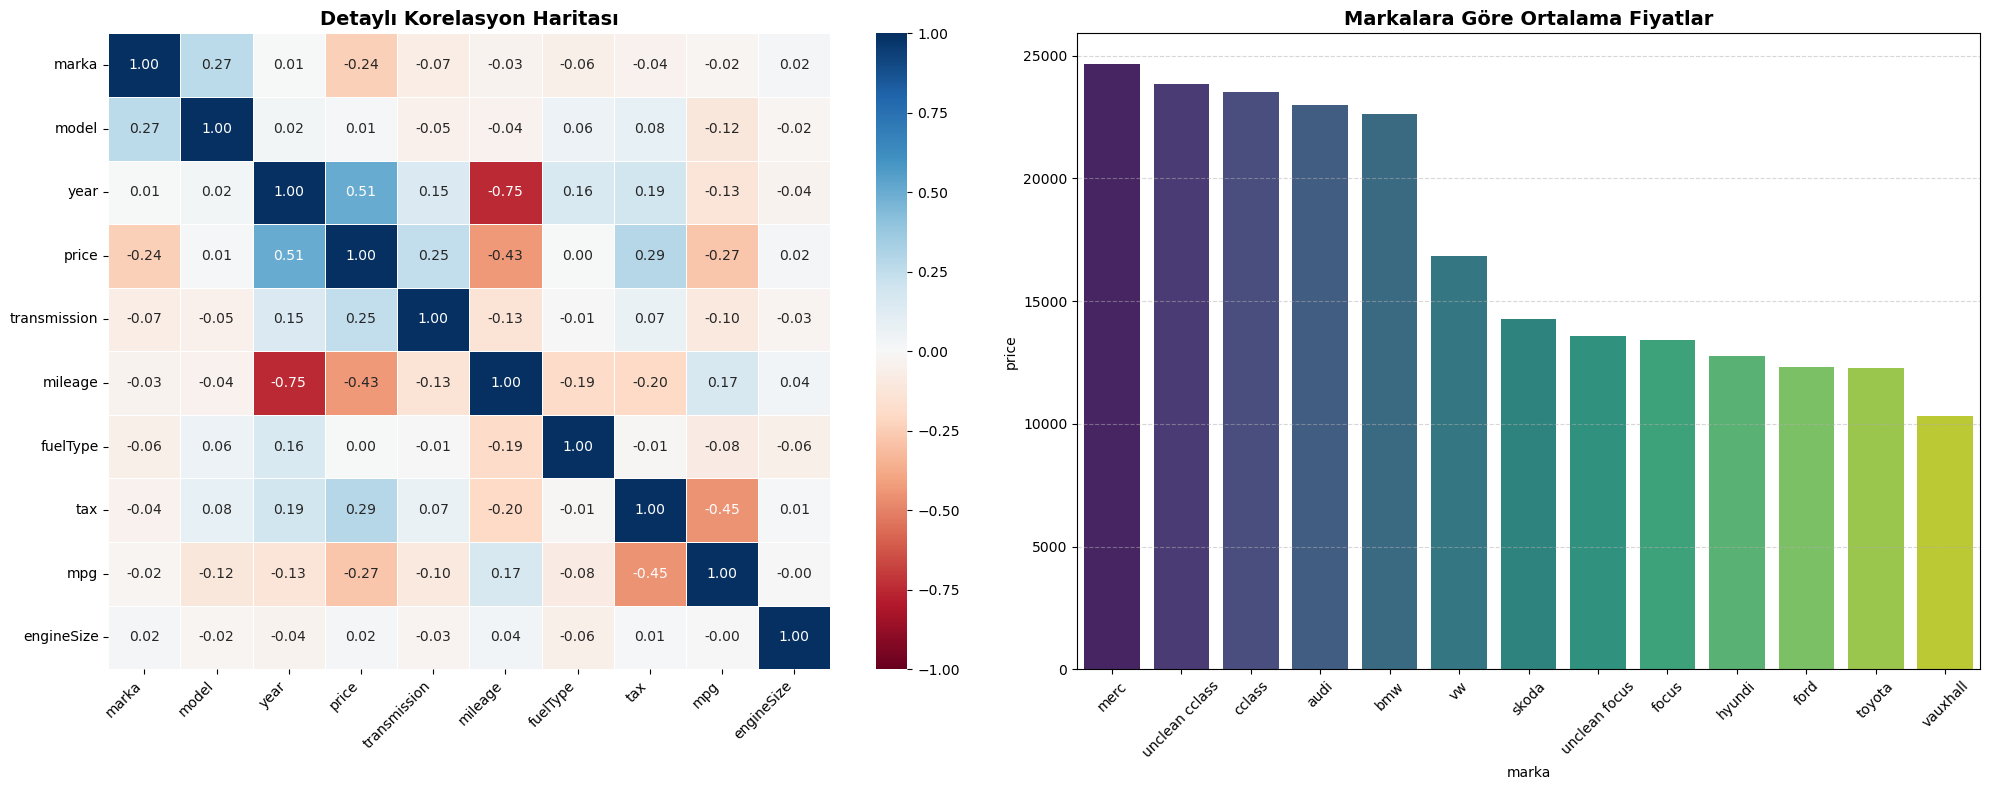

In [23]:
# EDA Kodları
df_viz = pd.read_csv('ekip_odevi_temizlenmis_veri.csv')
df_corr = df_viz.copy()
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

plt.figure(figsize=(20, 8))

# Grafik 1: Korelasyon
plt.subplot(1, 2, 1)
sns.heatmap(df_corr.corr(), annot=True, cmap='RdBu', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Detaylı Korelasyon Haritası', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Grafik 2: Marka Fiyat
plt.subplot(1, 2, 2)
avg_price = df_viz.groupby('marka')['price'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='marka', y='price', data=avg_price, palette='viridis')
plt.title('Markalara Göre Ortalama Fiyatlar', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# BÖLÜM 2: SENARYO ANALİZİ (Deneysel Tasarım)
### Amaç: Hangi Veri Yapısı Daha Başarılı?
Model performansını artırmak için **Güçlendirilmiş AdaBoost (Deep Tree Base)** kullanılarak 4 senaryo test edilmiştir:
1.  **AdaBoost (Ham Veri):** Sadece ölçeklenmiş veri.
2.  **AdaBoost + PCA:** %95 Varyans korumalı boyut indirgeme.
3.  **AdaBoost + Kümeleme:** K-Means segment bilgisi eklenmiş veri.
4.  **AdaBoost + Hibrit:** PCA ve Kümeleme bir arada. veri.

In [24]:
# Sonuçları saklayacak liste
senaryo_sonuclari = []

# --- 1. GÜÇLÜ MODEL FONKSİYONU ---
def get_strong_adaboost():
    return AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=10, random_state=42), # Derin Ağaç
        n_estimators=100, 
        learning_rate=0.1, 
        loss='linear',
        random_state=42
    )

# --- 2. METRİK HESAPLAYICI FONKSİYON ---
def hesapla_ve_ekle(senaryo_adi, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    # Listeye ekle
    senaryo_sonuclari.append({
        'Senaryo': senaryo_adi,
        'R2 Score': r2,
        'MAE (TL)': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'MSE': mse
    })
    
    print(f"-> {senaryo_adi} Tamamlandı. (R2: {r2:.4f})")

print("Analiz altyapısı hazır.")

Analiz altyapısı hazır.


### Senaryo 1: AdaBoost (Ham Veri)
Referans noktamızdır. Derin ağaç tabanlı AdaBoost modeli ham veri üzerinde eğitilir..

>>> Senaryo 1: AdaBoost (Ham) Çalışıyor...
-> 1. AdaBoost (Ham) Tamamlandı. (R2: 0.9141)


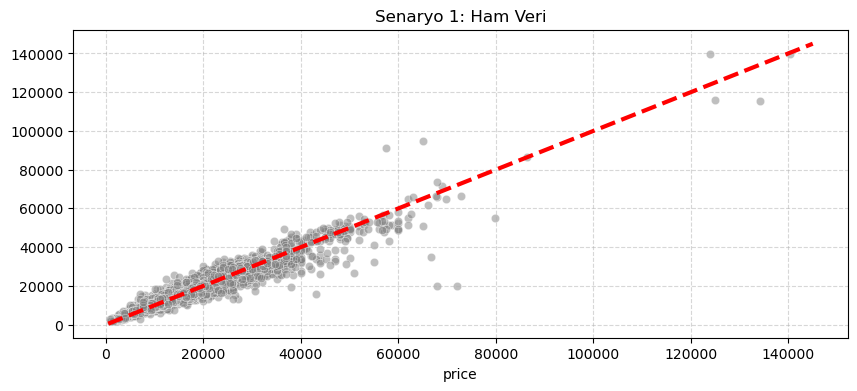

In [25]:
print(">>> Senaryo 1: AdaBoost (Ham) Çalışıyor...")

model_s1 = get_strong_adaboost()
model_s1.fit(X_train_scaled, y_train)
y_pred_s1 = model_s1.predict(X_test_scaled)

# Hesapla ve Kaydet
hesapla_ve_ekle('1. AdaBoost (Ham)', y_test, y_pred_s1)

# Görsel
plt.figure(figsize=(10, 4))
sns.scatterplot(x=y_test, y=y_pred_s1, alpha=0.5, color='gray', edgecolor='w')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=3)
plt.title('Senaryo 1: Ham Veri')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Senaryo 2: AdaBoost + PCA
Veri setindeki varyansın **%95'i** korunarak boyut indirgeme uygulanır..

>>> Senaryo 2: PCA Çalışıyor...
-> 2. PCA Tamamlandı. (R2: 0.9033)


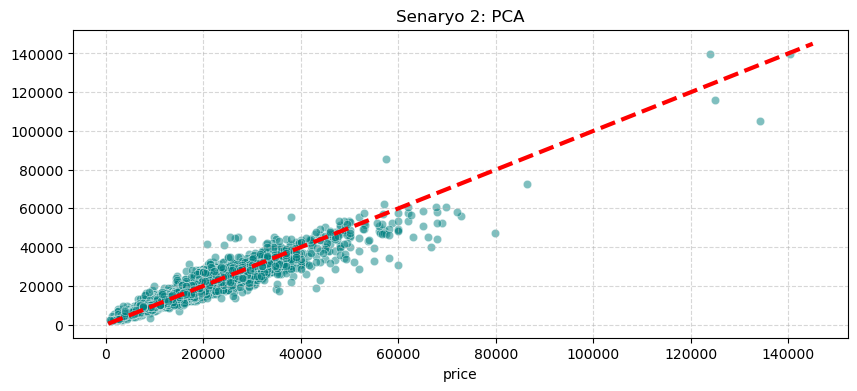

In [26]:
print(">>> Senaryo 2: PCA Çalışıyor...")

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

model_s2 = get_strong_adaboost()
model_s2.fit(X_train_pca, y_train)
y_pred_s2 = model_s2.predict(X_test_pca)

hesapla_ve_ekle('2. PCA', y_test, y_pred_s2)

plt.figure(figsize=(10, 4))
sns.scatterplot(x=y_test, y=y_pred_s2, alpha=0.5, color='teal', edgecolor='w')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=3)
plt.title('Senaryo 2: PCA')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Senaryo 3: AdaBoost + Kümeleme
K-Means (k=3) ile araçlar segmentlere ayrılır ve bu bilgi modele ek özellik olarak verilir.

>>> Senaryo 3: Kümeleme Çalışıyor...
-> 3. Kümeleme Tamamlandı. (R2: 0.8928)


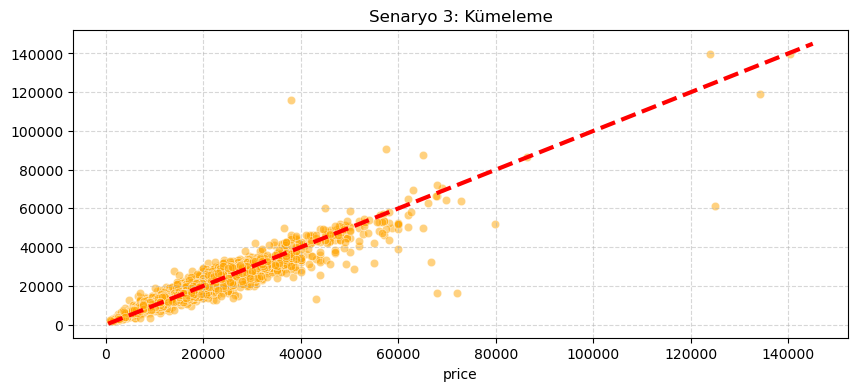

In [27]:
print(">>> Senaryo 3: Kümeleme Çalışıyor...")

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

X_train_cluster = np.hstack([X_train_scaled, train_clusters.reshape(-1, 1)])
X_test_cluster = np.hstack([X_test_scaled, test_clusters.reshape(-1, 1)])

model_s3 = get_strong_adaboost()
model_s3.fit(X_train_cluster, y_train)
y_pred_s3 = model_s3.predict(X_test_cluster)

hesapla_ve_ekle('3. Kümeleme', y_test, y_pred_s3)

plt.figure(figsize=(10, 4))
sns.scatterplot(x=y_test, y=y_pred_s3, alpha=0.5, color='orange', edgecolor='w')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=3)
plt.title('Senaryo 3: Kümeleme')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Senaryo 4: Hibrit (PCA + Kümeleme)
PCA ve Kümeleme tekniklerinin birlikte kullanıldığı en karmaşık veri yapısıdır.

>>> Senaryo 4: Hibrit Çalışıyor...
-> 4. Hibrit Tamamlandı. (R2: 0.8937)


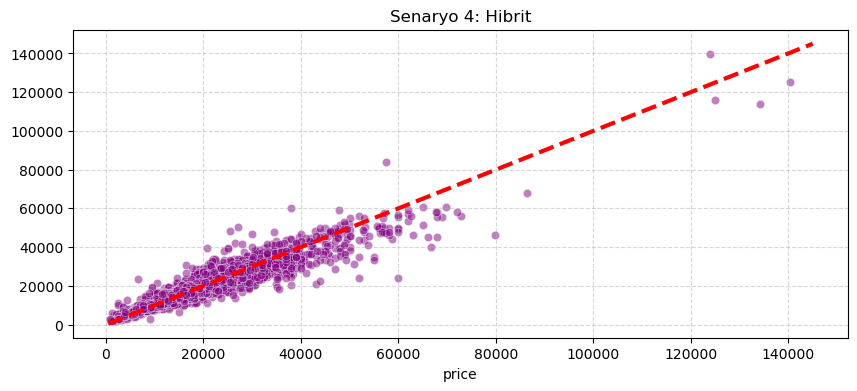

In [28]:
print(">>> Senaryo 4: Hibrit Çalışıyor...")

X_train_hybrid = np.hstack([X_train_pca, train_clusters.reshape(-1, 1)])
X_test_hybrid = np.hstack([X_test_pca, test_clusters.reshape(-1, 1)])

model_s4 = get_strong_adaboost()
model_s4.fit(X_train_hybrid, y_train)
y_pred_s4 = model_s4.predict(X_test_hybrid)

hesapla_ve_ekle('4. Hibrit', y_test, y_pred_s4)

plt.figure(figsize=(10, 4))
sns.scatterplot(x=y_test, y=y_pred_s4, alpha=0.5, color='purple', edgecolor='w')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=3)
plt.title('Senaryo 4: Hibrit')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Sonuçların Karşılaştırılması
Elde edilen 4 farklı skor grafiğe dökülerek, AdaBoost modeli için en uygun veri yapısı belirlenir.


>>> ADABOOST: SENARYO KARŞILAŞTIRMA TABLOSU <<<
             Senaryo  R2 Score     MAE (TL)         RMSE   MAPE (%)  \
0  1. AdaBoost (Ham)  0.914133  1828.548777  2874.940059  11.721745   
1             2. PCA  0.903271  1953.632532  3051.355918  12.509649   
2        3. Kümeleme  0.892820  1905.388992  3211.968281  12.297298   
3          4. Hibrit  0.893742  2052.392873  3198.128982  12.992525   

            MSE  
0  8.265280e+06  
1  9.310773e+06  
2  1.031674e+07  
3  1.022803e+07  


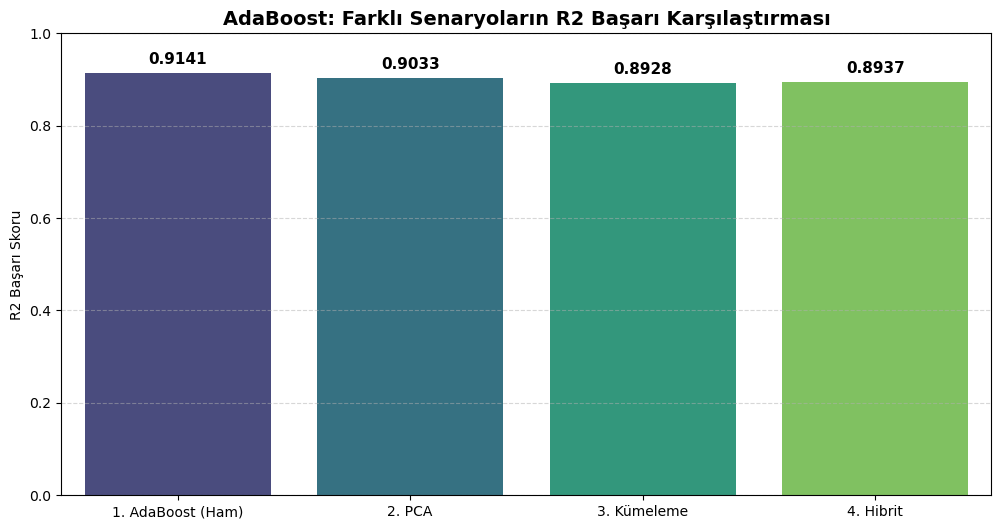

In [29]:
# 1. TABLO OLUŞTURMA
df_senaryo = pd.DataFrame(senaryo_sonuclari)

# Sütun sırasını düzenle
cols = ['Senaryo', 'R2 Score', 'MAE (TL)', 'RMSE', 'MAPE (%)', 'MSE']
df_senaryo = df_senaryo[cols]

print("\n" + "="*60)
print(">>> ADABOOST: SENARYO KARŞILAŞTIRMA TABLOSU <<<")
print("="*60)
print(df_senaryo)
print("="*60)

# 2. GRAFİK OLUŞTURMA (R2 Skoru)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Senaryo', y='R2 Score', data=df_senaryo, palette='viridis')

plt.title('AdaBoost: Farklı Senaryoların R2 Başarı Karşılaştırması', fontsize=14, fontweight='bold')
plt.ylim(0, 1.0)
plt.ylabel('R2 Başarı Skoru')
plt.xlabel('')

# Değerleri barların üzerine yaz
for i, v in enumerate(df_senaryo['R2 Score']):
    ax.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()